# TP4 :  Low-budget  Learning

# Introduction

**Context :**

Assume we are in a context where few "gold" labeled data are available for training, say

$$\mathcal{X}_{\text{train}} = \{(x_n,y_n)\}_{n\leq N_{\text{train}}}$$

where $N_{\text{train}}$ is small. Hence we are not in the context of classical well-organized benchmark datasets.

To make your life easier, you also get a validation set $\mathcal{X}_{\text{val}}$ representative of the test set, but you cannot use it for training. You can only use it to select the best model and hyperparameters.

A large test set $\mathcal{X}_{\text{test}}$ exists but is not accessible. We also assume that we have a limited computational budget (e.g., limited GPU access).


In this practical, we will use the `resnet10` architecture.

# QUESTIONS

## Grading

You will need to provide 4 files :
1. This Notebook
2. `utils.py`
3. `drawing_lora.png`
4. `cutmix.png`

Some of the code will be automatically graded so please follow the instructions carefully.

You will also need to participate in a competition on https://www.codabench.org to get your model evaluated on the hidden test set (the link to the competition will be provided on the course forum). Before submitting anything make sure to read the instructions on the competition page. The evaluation metric is the accuracy. However, *this is not a competition* as it is not necessary to get the best score to get a good grade. If you get a good score, and follow the instructions, you will get a good grade.

`utils.py` will be imported during the testing phase so please make sure:
- it does not execute any code when imported
- it does not depend on any module that is not standard (e.g., not `torch`, `torchvision`, `numpy`, etc.)


General instructions:
- Please provide clear and short answers between `<div class="alert alert-info">  <your answer>  </div>` tags (when it's not code).
- For each question that involves training a model:
    - Give the number of trained parameters.
    - You must provide the training curves (train & validation accuracy/loss vs epochs) in the notebook.
    - You must explain the choices you made (hyperparameters, etc). (A short justification is enough. For instance, "I used default hyperparameters." does not need further explanation. Or "I tried (0.1,0.01,0.001) and picked 0.01 because it gave the best validation accuracy." is enough.)
    - You must comment on the accuracy obtained.
- If you use a seed for reproducibility, please make sure it is a personal one using something like `hash("your_firstname_your_lastname")`.

<div class="alert alert-info">  Example of answer  </div>

In [1]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 26.3 MB/s eta 0:00:00


In [2]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
from torchmetrics.classification import ConfusionMatrix


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
import os

if not os.path.exists("data"):
    os.mkdir("data")
if not os.path.exists("data/TP4_images"):
    os.mkdir("data/TP4_images")
if not os.path.exists("data/TP4_images/north_dataset_test"):
    !cd data/TP4_images && wget -O north_dataset_train.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip" && unzip north_dataset_train.zip
    !cd data/TP4_images && wget -O north_dataset_test.zip  "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip" && unzip north_dataset_test.zip
dir_path = "data/TP4_images/"

In [6]:
import os
import urllib.request
import zipfile

# os.makedirs with exist_ok=True is a cleaner way to create nested directories safely
os.makedirs("data/TP4_images", exist_ok=True)

dir_path = "data/TP4_images/"
test_dir = os.path.join(dir_path, "north_dataset_test")

train_url = "https://nextcloud.lisn.upsaclay.fr/index.php/s/yzQRWE2YjmFn9WA/download/north_dataset_train.zip"
test_url = "https://nextcloud.lisn.upsaclay.fr/index.php/s/zntidWrFdYsGMDm/download/north_dataset_test.zip"

train_zip_path = os.path.join(dir_path, "north_dataset_train.zip")
test_zip_path = os.path.join(dir_path, "north_dataset_test.zip")

# Only download and extract if the test directory doesn't exist
if not os.path.exists(test_dir):
    print("Downloading train dataset... (this might take a moment)")
    urllib.request.urlretrieve(train_url, train_zip_path)
    print("Extracting train dataset...")
    with zipfile.ZipFile(train_zip_path, 'r') as zip_ref:
        zip_ref.extractall(dir_path)

    print("Downloading test dataset...")
    urllib.request.urlretrieve(test_url, test_zip_path)
    print("Extracting test dataset...")
    with zipfile.ZipFile(test_zip_path, 'r') as zip_ref:
        zip_ref.extractall(dir_path)

    print("Download and extraction complete!")
else:
    print("Datasets already exist. Ready to go!")

Datasets already exist. Ready to go!


In [7]:
val_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_test",
    transform=transforms.Compose([transforms.ToTensor()]),
)

train_dataset = datasets.ImageFolder(
    "data/TP4_images/north_dataset_sample",
    transform=transforms.Compose([transforms.ToTensor()]),
)


metric = ConfusionMatrix(task="multiclass", num_classes=2).to(device)


def model_instancier(**kwargs):
    """
    Instanciate a ResNet10 model (ResNet18 with only 1 block per layer).

    Parameters
    ----------
    **kwargs: dict
        Keyword arguments to pass to the ResNet18 constructor.

    Returns
    -------
    model: nn.Module
        The instantiated ResNet10 model.
    """
    _model = models.resnet18(**kwargs)
    for i in range(1, 5):
        setattr(_model, f"layer{i}", getattr(_model, f"layer{i}")[0])
    return _model


base_model = model_instancier()
classifier_name = "fc"


print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

Train dataset size: 42
Validation dataset size: 42


## Question 1:
>  Create `last_layer.py` to change the last layer of the resnet model so that it fits the problem.

In [8]:
from last_layer import LastLayer

setattr(base_model, classifier_name, LastLayer())
assert (
    getattr(base_model, classifier_name).out_features == 2
)  # we could also change the last layer to have 1 output. Do it with 2 so that it matches our tests procedure during grading.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cd /content/drive/MyDrive/TP4

/content/drive/MyDrive/TP4


## Question 2:
> Provide a function `precompute_features` in `utils.py` that creates a new dataset from the features precomputed by the model.

In [9]:
from torch.utils.data import DataLoader, TensorDataset
def precompute_features(
    model: nn.Module, dataset: torch.utils.data.Dataset, device: torch.device
) -> torch.utils.data.Dataset:

    # Set the model to evaluation mode
    model.eval()
    model = model.to(device)

    # Temporarily replace the final layer with Identity to extract features
    original_fc = model.fc
    model.fc = nn.Identity()

    # DataLoader to process the dataset (pq 64?)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False)

    all_features = []
    all_labels = []

    # Extract features without computing gradients !
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)

            # Extract features: outputs shape (batch_size, 512)
            features = model(images)

            # Move features to CPU so we don't run out of GPU memory
            # when storing the entire dataset
            all_features.append(features.cpu())
            all_labels.append(labels.cpu())

    # Restore the original final layer to the model
    model.fc = original_fc

    # Concatenate all batches into single tensors
    all_features = torch.cat(all_features, dim=0)
    all_labels = torch.cat(all_labels, dim=0)

    # Return a TensorDataset wrapping the precomputed data
    return TensorDataset(all_features, all_labels)

## Question 3:
> Train the last layer of a randomly initialized resnet model.  Provide the training process in the notebook with training curve. Comment on the accuracy.

In [10]:
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader
def train_and_evaluate_classifier(
    train_features,
    val_features,
    classifier_layer,
    device,
    num_epochs=20,
    batch_size=32,
    lr=0.001
):
    """
    Trains a linear classifier on precomputed features and plots the learning curves.
    """
    train_loader = DataLoader(train_features, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_features, batch_size=batch_size, shuffle=False)

    # Loss and optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier_layer.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("Starting training on ImageNet precomputed features...")

    # Training Loop
    for epoch in range(num_epochs):
        classifier_layer.train()
        running_loss, correct, total = 0.0, 0, 0

        for features, labels in train_loader:
            features, labels = features.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = classifier_layer(features)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            # Loss by image
            running_loss += loss.item() * features.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)

        # Valdiation
        classifier_layer.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for features, labels in val_loader:
                features, labels = features.to(device), labels.to(device)
                outputs = classifier_layer(features)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * features.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        history['val_loss'].append(running_loss / total)
        history['val_acc'].append(correct / total)

        # Print progress every 5 epochs and on the first epoch
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:02d}/{num_epochs} - "
                  f"Train Acc: {history['train_acc'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")

    # Plots
    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='blue')
    plt.plot(history['val_loss'], label='Validation Loss', color='orange')
    plt.title('Loss over Epochs (Pretrained base)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', color='blue')
    plt.plot(history['val_acc'], label='Validation Accuracy', color='orange')
    plt.title('Accuracy over Epochs (Pretrained base)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return history

In [11]:
from utils import precompute_features

In [13]:
base_model = model_instancier()
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

Starting training on ImageNet precomputed features...
Epoch 01/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 05/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 10/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 15/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 20/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 25/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 30/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 35/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 40/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 45/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 50/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 55/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 60/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 65/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 70/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 75/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 80/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 85/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 90/200 - Train Acc: 0.

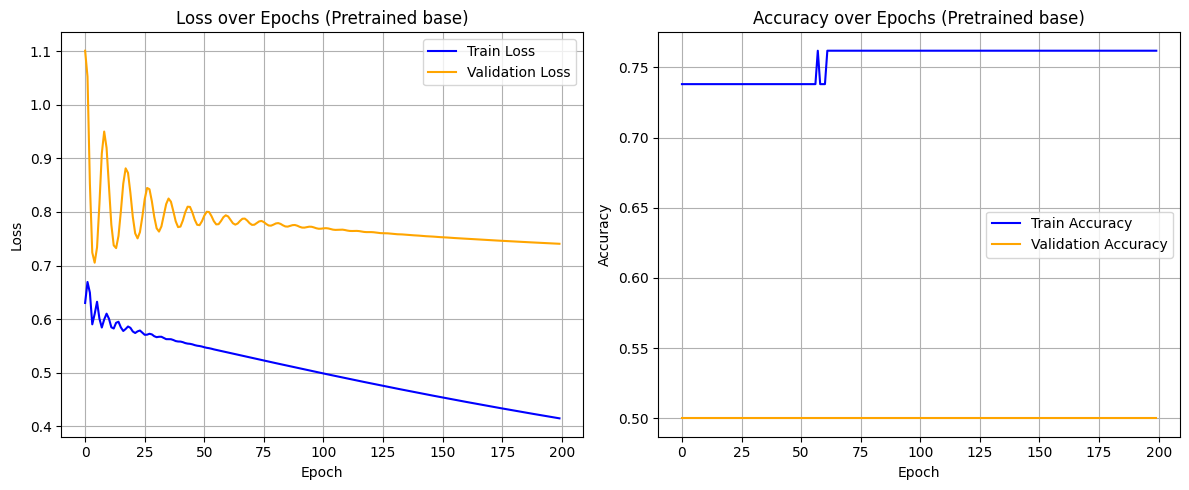

In [14]:
history = train_and_evaluate_classifier(
    train_features=train_features_dataset,
    val_features=val_features_dataset,
    classifier_layer=getattr(base_model, classifier_name),
    device=device,
    num_epochs=200,
    batch_size=64,
    lr=0.01)
#jusitifier le batchsize et le lr: ça donne a peu pres la meme chose pour
#lr=0.01 ,0.001 ou 0.0001
#batchsize petit --> accuarcy qui oscille bcp
#si lr=0.0001 loss val croit !!!
#0.001 ça decroit
#0.01 ça decroit vrt bien

1. Validation Accuracy at 50% (Random Guessing): Since this is a binary classification task (2 classes), a 50% validation accuracy means the model is performing no better than a random coin flip. This is exactly what we expect. Because the base ResNet model was randomly initialized and frozen, its convolutional layers (g(x)) are not extracting any meaningful visual features (like edges or textures). It is essentially outputting a random 512-dimensional vector for every image.

2. Training Accuracy at ~74% (Overfitting to Noise): The linear classifier (our LastLayer) is trying to find a boundary to separate the two classes based on these random 512-dimensional vectors. Because 512 dimensions give the model a lot of mathematical flexibility, it manages to memorize some random noise patterns in the training data, pushing the training accuracy to ~74%. However, because these patterns are purely random and have nothing to do with the actual images, this "knowledge" completely fails to generalize to the validation set.

Conclusion: Training only the last layer of a randomly initialized feature extractor does not work. For this approach to be effective, the base model needs to be pre-trained on a large dataset so it can provide meaningful representations to the final layer.

## Question 4:
>  Now start from a pretrained model on imagenet (https://pytorch.org/vision/stable/models.html#) and only train the last layer. Provide the training process in the notebook with training curve.

This is the first question evaluated on the codabench platform.

In [38]:
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())
base_model = base_model.to(device)

In [22]:
train_features_dataset = precompute_features(base_model, train_dataset, device=device)
val_features_dataset = precompute_features(base_model, val_dataset, device=device)

Starting training on ImageNet precomputed features...
Epoch 01/200 - Train Acc: 0.3095 - Val Acc: 0.5000
Epoch 05/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 10/200 - Train Acc: 0.7619 - Val Acc: 0.5000
Epoch 15/200 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 20/200 - Train Acc: 0.8810 - Val Acc: 0.6905
Epoch 25/200 - Train Acc: 0.8571 - Val Acc: 0.6190
Epoch 30/200 - Train Acc: 0.8810 - Val Acc: 0.6905
Epoch 35/200 - Train Acc: 0.9048 - Val Acc: 0.7143
Epoch 40/200 - Train Acc: 0.8810 - Val Acc: 0.7143
Epoch 45/200 - Train Acc: 0.9286 - Val Acc: 0.7619
Epoch 50/200 - Train Acc: 0.9286 - Val Acc: 0.7619
Epoch 55/200 - Train Acc: 0.9286 - Val Acc: 0.7619
Epoch 60/200 - Train Acc: 0.9286 - Val Acc: 0.7857
Epoch 65/200 - Train Acc: 0.9524 - Val Acc: 0.7857
Epoch 70/200 - Train Acc: 0.9524 - Val Acc: 0.8095
Epoch 75/200 - Train Acc: 0.9524 - Val Acc: 0.8095
Epoch 80/200 - Train Acc: 0.9524 - Val Acc: 0.8095
Epoch 85/200 - Train Acc: 0.9524 - Val Acc: 0.8333
Epoch 90/200 - Train Acc: 0.

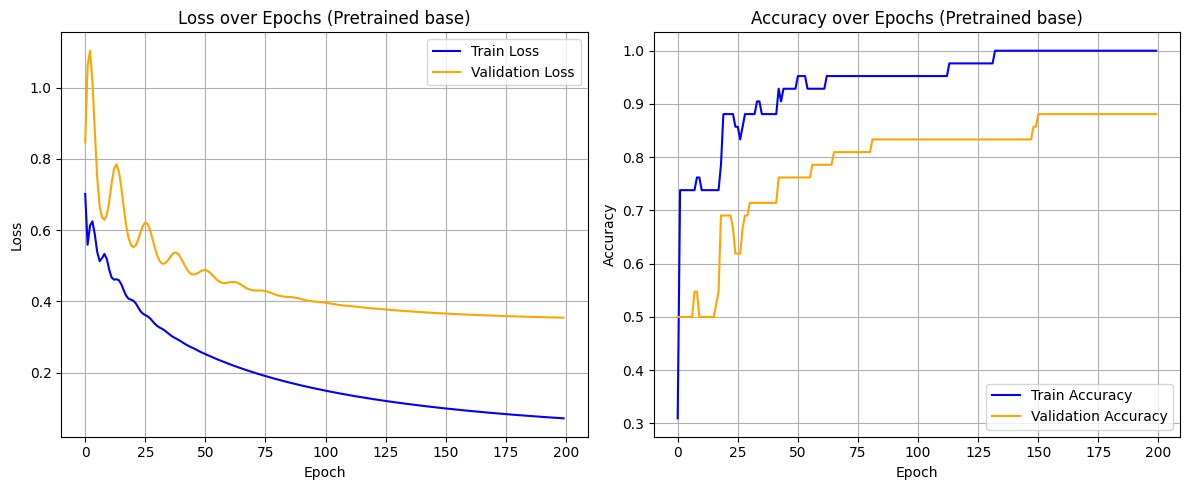

In [39]:
# Extract the classifier layer to pass into our function
classifier = getattr(base_model, classifier_name).to(device)

# Train the layer and plot the results
history = train_and_evaluate_classifier(
    train_features=train_features_dataset,
    val_features=val_features_dataset,
    classifier_layer=classifier,
    device=device,
    num_epochs=200,
    batch_size=64,
    lr=0.01
)

#apres 200 epoch on a la même valeur pour l'accuracy
#lr 0.01 decroit et bonne accracy
# lr 0.001 ou moins valeur d'accuracy basse si juste 200 epochs
#batch size 32 ou moins , ça oscille


<div class="alert alert-info">  You should achieve >80% accuracy on the val set.  </div>

### Save your model

In [40]:
# Save the last layer weights for grading on codabench
torch.save(getattr(base_model, classifier_name).state_dict(), "last_layer_finetune.pth")

### Check that you can load your model

In [41]:
model = model_instancier(weights="DEFAULT")
fc = LastLayer()
fc.load_state_dict(
    torch.load("last_layer_finetune.pth", weights_only=True, map_location=device)
)
setattr(model, classifier_name, fc)
model.eval()
pass

## Question 5:
> Perform  LoRA https://arxiv.org/pdf/2106.09685  on the model  ( We are perfectly fine if you use external library for this question only )

Intermediate question : Describe LoRA and the difference with LoRA for Convolutions in this paper : https://arxiv.org/pdf/2401.17868  in a few lines  (you do not have to implement ConvLora)

In [80]:
from peft import LoraConfig, get_peft_model

# Start fresh with a pretrained model and our custom last layer
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())

# LoRA Configuration
lora_config = LoraConfig(
    r=8,                  # Rank of the update matrices (lower = fewer parameters)
    lora_alpha=16,        # Scaling factor for the LoRA updates
    target_modules=["conv1", "conv2"], # Targets the Conv2d layers in ResNet blocks
    lora_dropout=0.1,     # Dropout probability for LoRA layers
    bias="none",          # Bias handling
    modules_to_save=[classifier_name] # Tells PEFT to keep our custom fc layer fully trainable!
)

# Wrap the base model with the LoRA model
lora_model = get_peft_model(base_model, lora_config)
lora_model = lora_model.to(device)

# Print the parameter reduction to see the advantage of LoRA
lora_model.print_trainable_parameters()

trainable params: 124,058 || all params: 5,030,876 || trainable%: 2.4659


In [43]:
def train_lora_model(
    model,
    train_data,
    val_data,
    device,
    num_epochs=10,
    batch_size=32,
    lr=0.001
):

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    # loss and optimizer
    # Notice we pass model.parameters() because PEFT automatically handles
    # freezing the base weights and only passing the LoRA + classifier weights to the optimizer.
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("Starting LoRA fine-tuning on raw images...")

    # Training Loop
    for epoch in range(num_epochs):
        # Training-
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            # Forward pass now goes through the entire ResNet + LoRA layers
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)

        # Validation
        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        history['val_loss'].append(running_loss / total)
        history['val_acc'].append(correct / total)

        print(f"Epoch {epoch+1:02d}/{num_epochs} - "
              f"Train Acc: {history['train_acc'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")


    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='purple')
    plt.plot(history['val_loss'], label='Validation Loss', color='green')
    plt.title('Loss over Epochs (LoRA)')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', color='purple')
    plt.plot(history['val_acc'], label='Validation Accuracy', color='green')
    plt.title('Accuracy over Epochs (LoRA)')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return history

Starting LoRA fine-tuning on raw images...
Epoch 01/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 02/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 03/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 04/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 05/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 06/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 07/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 08/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 09/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 10/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 11/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 12/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 13/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 14/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 15/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 16/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 17/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 18/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 19/90 - Train Acc: 0.7381 - Val Acc: 0.5000
Epoch 2

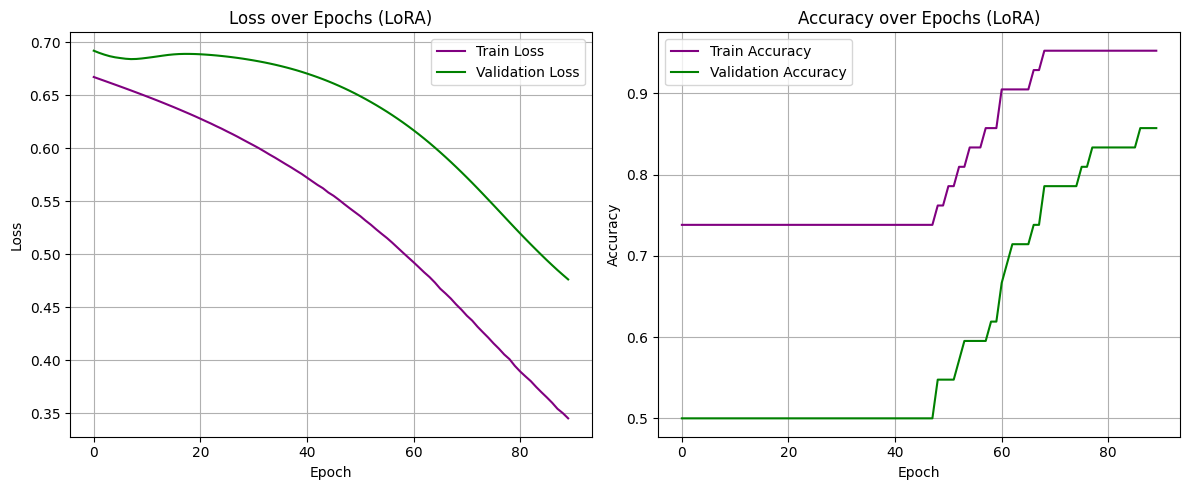

In [81]:
# We use fewer epochs here because full-image passes take longer,
# and LoRA usually converges quite efficiently.
lora_history = train_lora_model(
    model=lora_model,
    train_data=train_dataset,
    val_data=val_dataset,
    device=device,
    num_epochs=90,
    batch_size=64,
    lr=0.0001
)
# This learning rate with this number of epocs allows to achieve an accuracy higher than 80%
# withought overfiitng
#C'est vrt trop aleatoire....
# si lr plus grand et num epoch plus pettit , vrt aleatoire et la loss de la vlaidation croit à la fin
# Je pense c'est le sweetspot, j'ai répeté l'ep 3 fois et ça me donne les mêm resultats contrairement
#quand le lr est plus grand et num d'epoch plus petit

Decrire c'est quoi lora

There is overfitting

## Question 6:
> Let's do some Data Augmentation https://en.wikipedia.org/wiki/Data_augmentation . Load some alteration of the data from the `torchvision.transforms` module and incorporate them into your training pipeline.

Intermediate question : Check CutMix  (https://pytorch.org/vision/stable/auto_examples/transforms/plot_cutmix_mixup.html#sphx-glr-auto-examples-transforms-plot-cutmix-mixup-py) and explain it with a small drawing.

You can find many other data augmentation techniques here: https://docs.pytorch.org/vision/0.15/transforms.html

This is the second question evaluated on the codabench platform.

In [144]:
base_model = model_instancier(weights="DEFAULT")
setattr(base_model, classifier_name, LastLayer())

# LoRA Configuration
lora_config = LoraConfig(
    r=8,                  # Rank of the update matrices (lower = fewer parameters)
    lora_alpha=16,        # Scaling factor for the LoRA updates
    target_modules=["conv1", "conv2"], # Targets the Conv2d layers in ResNet blocks
    lora_dropout=0.1,     # Dropout probability for LoRA layers
    bias="none",          # Bias handling
    modules_to_save=[classifier_name] # Tells PEFT to keep our custom fc layer fully trainable!
)

# Wrap the base model with the LoRA model
lora_model_aug = get_peft_model(base_model, lora_config)
lora_model_aug = lora_model_aug.to(device)

# Print the parameter reduction to see the advantage of LoRA
lora_model_aug.print_trainable_parameters()

trainable params: 124,058 || all params: 5,030,876 || trainable%: 2.4659


In [110]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
import utils  # Ton fichier contenant apply_lora
from torchvision.transforms import v2
# --- 1. Transformations avec Data Augmentation ---
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Validation : Pas d'augmentation aléatoire, juste Resize/Crop
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Chargement des datasets
train_dataset_aug = datasets.ImageFolder("data/TP4_images/north_dataset_sample", transform=train_transform)
val_dataset = datasets.ImageFolder("data/TP4_images/north_dataset_test", transform=val_transform)

train_loader = DataLoader(train_dataset_aug, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# --- 2. Définition de CutMix ---
# CutMix prend deux images, découpe un morceau de l'une pour le coller sur l'autre.
# Cela force le modèle à reconnaître les objets à partir de morceaux partiels.
cutmix = v2.CutMix(num_classes=2, alpha=1.0)
# Note : Si ta version de torchvision ne l'a pas, on le fait souvent dans la boucle de train.

In [100]:
from torchvision.transforms import v2

def train_lora_model_with_cutmix(
    model,
    train_data,
    val_data,
    device,
    num_epochs=10,
    batch_size=32,
    lr=0.001
):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)

    # Le critère CrossEntropyLoss gère nativement les labels de CutMix (probabilités)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Initialisation de CutMix (2 classes : North vs South)
    cutmix = v2.CutMix(num_classes=2, alpha=1.0)

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print("Starting LoRA fine-tuning with CutMix...")

    for epoch in range(num_epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            # --- APPLICATION DE CUTMIX ---
            # Transforme les labels en vecteurs (ex: [0.7, 0.3])
            images, labels = cutmix(images, labels)
            # -----------------------------

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            # Pour l'Accuracy au train avec CutMix :
            # On compare la prédiction à la classe qui est majoritaire dans le mélange
            _, predicted = outputs.max(1)
            _, labels_indices = labels.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels_indices).sum().item()

        history['train_loss'].append(running_loss / total)
        history['train_acc'].append(correct / total)

        # Validation (SANS CutMix sur la validation !)
        model.eval()
        running_loss, correct, total = 0.0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        history['val_loss'].append(running_loss / total)
        history['val_acc'].append(correct / total)

        print(f"Epoch {epoch+1:02d}/{num_epochs} - "
              f"Train Acc: {history['train_acc'][-1]:.4f} - Val Acc: {history['val_acc'][-1]:.4f}")

    # Affichage des courbes
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='purple')
    plt.plot(history['val_loss'], label='Validation Loss', color='green')
    plt.title('Loss (LoRA + CutMix)')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Accuracy', color='purple')
    plt.plot(history['val_acc'], label='Validation Accuracy', color='green')
    plt.title('Accuracy (LoRA + CutMix)')
    plt.legend()
    plt.grid(True)
    plt.show()

    return history

Starting LoRA fine-tuning with CutMix...
Epoch 01/300 - Train Acc: 0.2857 - Val Acc: 0.5000
Epoch 02/300 - Train Acc: 0.2619 - Val Acc: 0.5000
Epoch 03/300 - Train Acc: 0.2857 - Val Acc: 0.5000
Epoch 04/300 - Train Acc: 0.3095 - Val Acc: 0.5000
Epoch 05/300 - Train Acc: 0.2857 - Val Acc: 0.5000
Epoch 06/300 - Train Acc: 0.2619 - Val Acc: 0.5000
Epoch 07/300 - Train Acc: 0.2143 - Val Acc: 0.5000
Epoch 08/300 - Train Acc: 0.2857 - Val Acc: 0.5000
Epoch 09/300 - Train Acc: 0.2381 - Val Acc: 0.5000
Epoch 10/300 - Train Acc: 0.2857 - Val Acc: 0.5000
Epoch 11/300 - Train Acc: 0.3333 - Val Acc: 0.5000
Epoch 12/300 - Train Acc: 0.3095 - Val Acc: 0.5000
Epoch 13/300 - Train Acc: 0.3810 - Val Acc: 0.5000
Epoch 14/300 - Train Acc: 0.3333 - Val Acc: 0.5000
Epoch 15/300 - Train Acc: 0.2381 - Val Acc: 0.5238
Epoch 16/300 - Train Acc: 0.2857 - Val Acc: 0.5238
Epoch 17/300 - Train Acc: 0.3333 - Val Acc: 0.5238
Epoch 18/300 - Train Acc: 0.4048 - Val Acc: 0.5238
Epoch 19/300 - Train Acc: 0.3095 - Val Ac

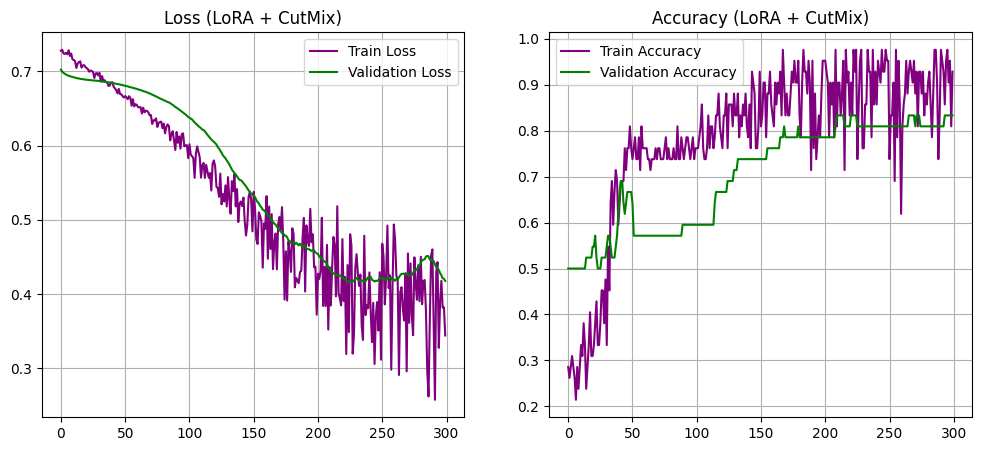

In [145]:
lora_history = train_lora_model_with_cutmix(
    model=lora_model_aug,
    train_data=train_dataset_aug,
    val_data=val_dataset,
    device=device,
    num_epochs=300,
    batch_size=64,
    lr=0.00006
)
#je pense qu'il faut mettre ces trucs dans utiles là

In [148]:
import torch
import torch.nn as nn
from torchvision import models

# 1. Créer une instance propre du modèle (structure ResNet standard)
merged_model = model_instancier() # ou models.resnet18() selon ton TP

# 2. On passe tout en mode évaluation
lora_model_aug.eval()
lora_model_aug.to('cpu')
merged_model.to('cpu')

# 3. Fusion des poids
with torch.no_grad():
    # On récupère les dictionnaires de poids
    lora_sd = lora_model_aug.state_dict()
    merged_sd = merged_model.state_dict()

    for name, module in lora_model_aug.named_modules():
        # Si le module possède les attributs LoRA
        if hasattr(module, 'lora_A'):
            # On récupère le poids original (W)
            # Puisque le module est la couche elle-même, on prend .weight
            W_orig = module.weight

            # Récupération de A, B et du scaling
            A = module.lora_A
            B = module.lora_B
            scaling = getattr(module, 'scaling', 1.0) # On prend 1.0 si scaling n'existe pas

            # Calcul du Delta W = (B @ A) * scaling
            # Note : Pour les Conv2d, il faut souvent faire un view/reshape
            # mais si c'est du Linear, B @ A suffit.
            if isinstance(module, nn.Conv2d):
                # Pour Conv2d, on reshape B @ A pour correspondre à (out, in, k, k)
                delta_w = (B @ A).view(W_orig.shape) * scaling
            else:
                # Pour Linear
                delta_w = (B @ A) * scaling

            # Calcul du poids final
            W_merged = W_orig + delta_w

            # Copie dans le modèle final
            merged_sd[f"{name}.weight"].copy_(W_merged)

            # Copie du biais s'il existe
            if module.bias is not None:
                merged_sd[f"{name}.bias"].copy_(module.bias)

        # Pour les couches sans LoRA (BatchNorm, etc.) et la couche finale 'fc'
        else:
            # On vérifie si c'est une couche avec des paramètres (pas un container)
            if hasattr(module, 'weight') and not isinstance(module, (nn.Sequential, nn.ModuleList)):
                if f"{name}.weight" in merged_sd:
                    merged_sd[f"{name}.weight"].copy_(module.weight)
                if module.bias is not None and f"{name}.bias" in merged_sd:
                    merged_sd[f"{name}.bias"].copy_(module.bias)

# Charger les poids fusionnés dans le modèle final
merged_model.load_state_dict(merged_sd)

# 4. Sauvegarde
assert isinstance(merged_model, models.ResNet)
torch.save(merged_model.state_dict(), "final_model.pth")
print("✅ Modèle fusionné avec succès dans 'final_model.pth'")

TypeError: unsupported operand type(s) for @: 'ModuleDict' and 'ModuleDict'

In [149]:
# 1. Fusionner les poids LoRA avec le modèle de base
# Cette fonction de PEFT s'occupe de calculer W + (B @ A) et de supprimer les couches LoRA
merged_model = lora_model_aug.merge_and_unload()

# 2. Vérifier que c'est bien un ResNet (ou la classe de ton modèle de base)
# Note : merge_and_unload renvoie le modèle de base (base_model) mis à jour
print(type(merged_model))

# 3. Passer le modèle sur CPU pour la sauvegarde (recommandé pour la compatibilité)
merged_model = merged_model.to('cpu')

# 4. Sauvegarder le state_dict
# Le fichier final ne contiendra que les poids d'un ResNet standard
torch.save(merged_model.state_dict(), "final_model.pth")

print("✅ Fusion terminée et modèle sauvegardé dans 'final_model.pth'")

<class 'torchvision.models.resnet.ResNet'>
✅ Fusion terminée et modèle sauvegardé dans 'final_model.pth'


### Save your model

In [146]:
# Merge LoRA weights back into the base model
merged_model = None  # TODO: Merge LoRA weights back into the base model
assert isinstance(merged_model, models.ResNet)

torch.save(merged_model.state_dict(), "final_model.pth")

AssertionError: 

### Check that you can load your model

In [150]:
from last_layer import LastLayer

classifier_name = "fc"
device = torch.device("cpu")
model = model_instancier()
setattr(model, classifier_name, LastLayer())

model.load_state_dict(
    torch.load("final_model.pth", weights_only=True, map_location=device)
)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (layer2): BasicBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(128, 128, kernel

<div class="alert alert-info">  With LoRA and Data Augmentation you should be able to improve your model's performance compared to only fine-tuning the last layer. </div>

# Some advice

In our experiments, we only used SGD and a laptop GPU. We recommend not hesitating to use a large number of epochs (e.g., 100, 200, etc.). We did not use any learning rate scheduler but you can try if you want. Many data augmentation techniques exist, you can try them and see if they improve your performance. You can also try to combine them. For instance, you can try to combine CutMix with some geometric transformations (e.g., random crop, random horizontal flip, etc.).

The improvement from LoRA and data augmentation is quite hard to see on the small validation set. If you get even a small improvement on the validation set, it is likely that you will get a better score on the test set, except if you overfit the validation set. With an honest improvement on the validation set, you should be able to get a good grade.